# Assignment 4 – Tree & Graph Visualizations
**Course:** Data Visualization  
**Dataset:** Shopify E-Commerce Sales Dataset (60,000 orders)  
**Source:** [Kaggle – Shopify Sales Dataset ML EDA](https://www.kaggle.com/datasets/hamzaansari08/shopify-sales-dataset-ml-eda)

## 🔗 GitHub Pages Link
**[View Visualizations Online](https://YOUR-USERNAME.github.io/dataviz-a4/)**  
*(Replace with your actual GitHub Pages URL after uploading)*

---

## Dataset Descriptions

### 🌳 Tree Dataset — Shopify E-Commerce Sales (Hierarchical View)
**Source:** Kaggle Shopify Sales Dataset ML EDA  
**Structure:** A 3-level hierarchy constructed from the sales data:

| Level | Node Represents |
|-------|----------------|
| Root | "Shopify Store" (global) |
| Level 1 | Customer Country (7 countries) |
| Level 2 | Product Category (7 categories) |
| Level 3 (leaf) | Traffic Source (5 sources) |

**Nodes** represent aggregation points — the store as a whole, then countries, then product categories, then acquisition channels.  
**Edges** represent the parent-child containment relationship (e.g., a sale in USA → Electronics → Paid Ads flows up this hierarchy).

---

### 🔗 Graph Dataset — Payment × Country Co-occurrence Network
**Source:** Same Shopify Sales Dataset  
**Structure:** An undirected bipartite graph:

| Element | Represents |
|---------|-----------|
| **Nodes (type A)** | Customer Countries (7 nodes) |
| **Nodes (type B)** | Payment Methods (5 nodes) |
| **Edges** | Connection between country and payment method used |
| **Edge Weight** | Number of orders using that payment method in that country |

---


## 1. Setup & Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.colors as mcolors
import networkx as nx
import base64, os, warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.facecolor': '#0f1117',
    'axes.facecolor':   '#0f1117',
    'text.color':       'white',
    'font.family':      'DejaVu Sans',
    'font.size':        10,
})

# Helper: save figure AND return base64 string (used later for HTML export)
_saved_images = {}   # filename -> base64 string

def save_fig(fig, filename):
    fig.savefig(filename, dpi=150, bbox_inches='tight', facecolor='#0f1117')
    with open(filename, 'rb') as f:
        _saved_images[filename] = base64.b64encode(f.read()).decode()
    print(f"Saved → {filename}  ({os.path.getsize(filename)//1024} KB)")

print("✅ All libraries loaded")


✅ All libraries loaded


## 2. Load & Preview Dataset

In [2]:
df = pd.read_csv("shopify_sales_dataset_ml_eda.csv")
print(f"Shape: {df.shape}")
print(f"Countries : {sorted(df['customer_country'].unique())}")
print(f"Categories: {sorted(df['product_category'].unique())}")
print(f"Traffic   : {sorted(df['traffic_source'].unique())}")
print(f"Payments  : {sorted(df['payment_method'].unique())}")
df.head(3)


Shape: (60000, 17)
Countries : ['Australia', 'Canada', 'Germany', 'India', 'UAE', 'UK', 'USA']
Categories: ['Accessories', 'Beauty', 'Electronics', 'Fashion', 'Footwear', 'Home Decor', 'Sports']
Traffic   : ['Direct', 'Email', 'Organic', 'Paid Ads', 'Social Media']
Payments  : ['Apple Pay', 'Cash on Delivery', 'Credit Card', 'Debit Card', 'PayPal']


,order_id,order_date,customer_id,product_id,product_category,product_price,discount_percent,quantity,customer_country,traffic_source,payment_method,shipping_cost,rating,is_returned,discounted_price,revenue,profit
0,1,2023-04-13,14958,7824,Accessories,143.39,40,1,USA,Paid Ads,Credit Card,21.08,2.0,0,86.03,86.03,64.95
1,2,2024-03-11,26825,5557,Sports,746.49,15,4,UAE,Email,PayPal,5.48,3.7,0,634.52,2538.08,2532.60
2,3,2025-05-10,37450,2225,Electronics,641.06,5,5,Canada,Paid Ads,Apple Pay,11.27,3.2,0,609.01,3045.05,3033.78


---
## 🌳 PART A: TREE VISUALIZATION

### 3. Build Hierarchy: Store → Country → Category → Traffic Source


In [3]:
tree_agg = (df.groupby(['customer_country','product_category','traffic_source'])
              ['revenue'].sum().reset_index())
tree_agg.columns = ['country','category','traffic','revenue']

T = nx.DiGraph()
T.add_node("Shopify Store", level=0, revenue=df['revenue'].sum())

for country, grp1 in tree_agg.groupby('country'):
    country_rev = grp1['revenue'].sum()
    T.add_node(country, level=1, revenue=country_rev)
    T.add_edge("Shopify Store", country, weight=country_rev)
    for category, grp2 in grp1.groupby('category'):
        cat_node = f"{country}\n{category}"
        cat_rev  = grp2['revenue'].sum()
        T.add_node(cat_node, level=2, revenue=cat_rev)
        T.add_edge(country, cat_node, weight=cat_rev)
        for _, row in grp2.iterrows():
            leaf = f"{country}\n{category}\n{row['traffic']}"
            T.add_node(leaf, level=3, revenue=row['revenue'])
            T.add_edge(cat_node, leaf, weight=row['revenue'])

print(f"Nodes: {T.number_of_nodes()} | Edges: {T.number_of_edges()}")
print(f"Is DAG: {nx.is_directed_acyclic_graph(T)}")

LEVEL_COLORS = {0:'#f59e0b', 1:'#6366f1', 2:'#10b981', 3:'#f43f5e'}
LEVEL_SIZES  = {0:1800,      1:900,       2:400,       3:150}

def node_attrs(G):
    levels = nx.get_node_attributes(G, 'level')
    colors = [LEVEL_COLORS.get(levels.get(n,3),'#aaa') for n in G.nodes()]
    sizes  = [LEVEL_SIZES.get(levels.get(n,3),100)     for n in G.nodes()]
    return colors, sizes

def hierarchy_pos(G, root, width=1.0, vert_gap=0.25):
    def _pos(G, node, left, right, vert_loc, pos):
        children = list(G.successors(node))
        pos[node] = ((left+right)/2, vert_loc)
        if children:
            dx = (right-left)/len(children)
            nx_ = left
            for child in children:
                _pos(G, child, nx_, nx_+dx, vert_loc-vert_gap, pos)
                nx_ += dx
        return pos
    return _pos(G, root, 0, width, 0, {})


Nodes: 302 | Edges: 301
Is DAG: True


### 4A. Tree Layout 1 — Top-Down Hierarchical Layout

Saved → tree_layout1_topdown.png  (488 KB)


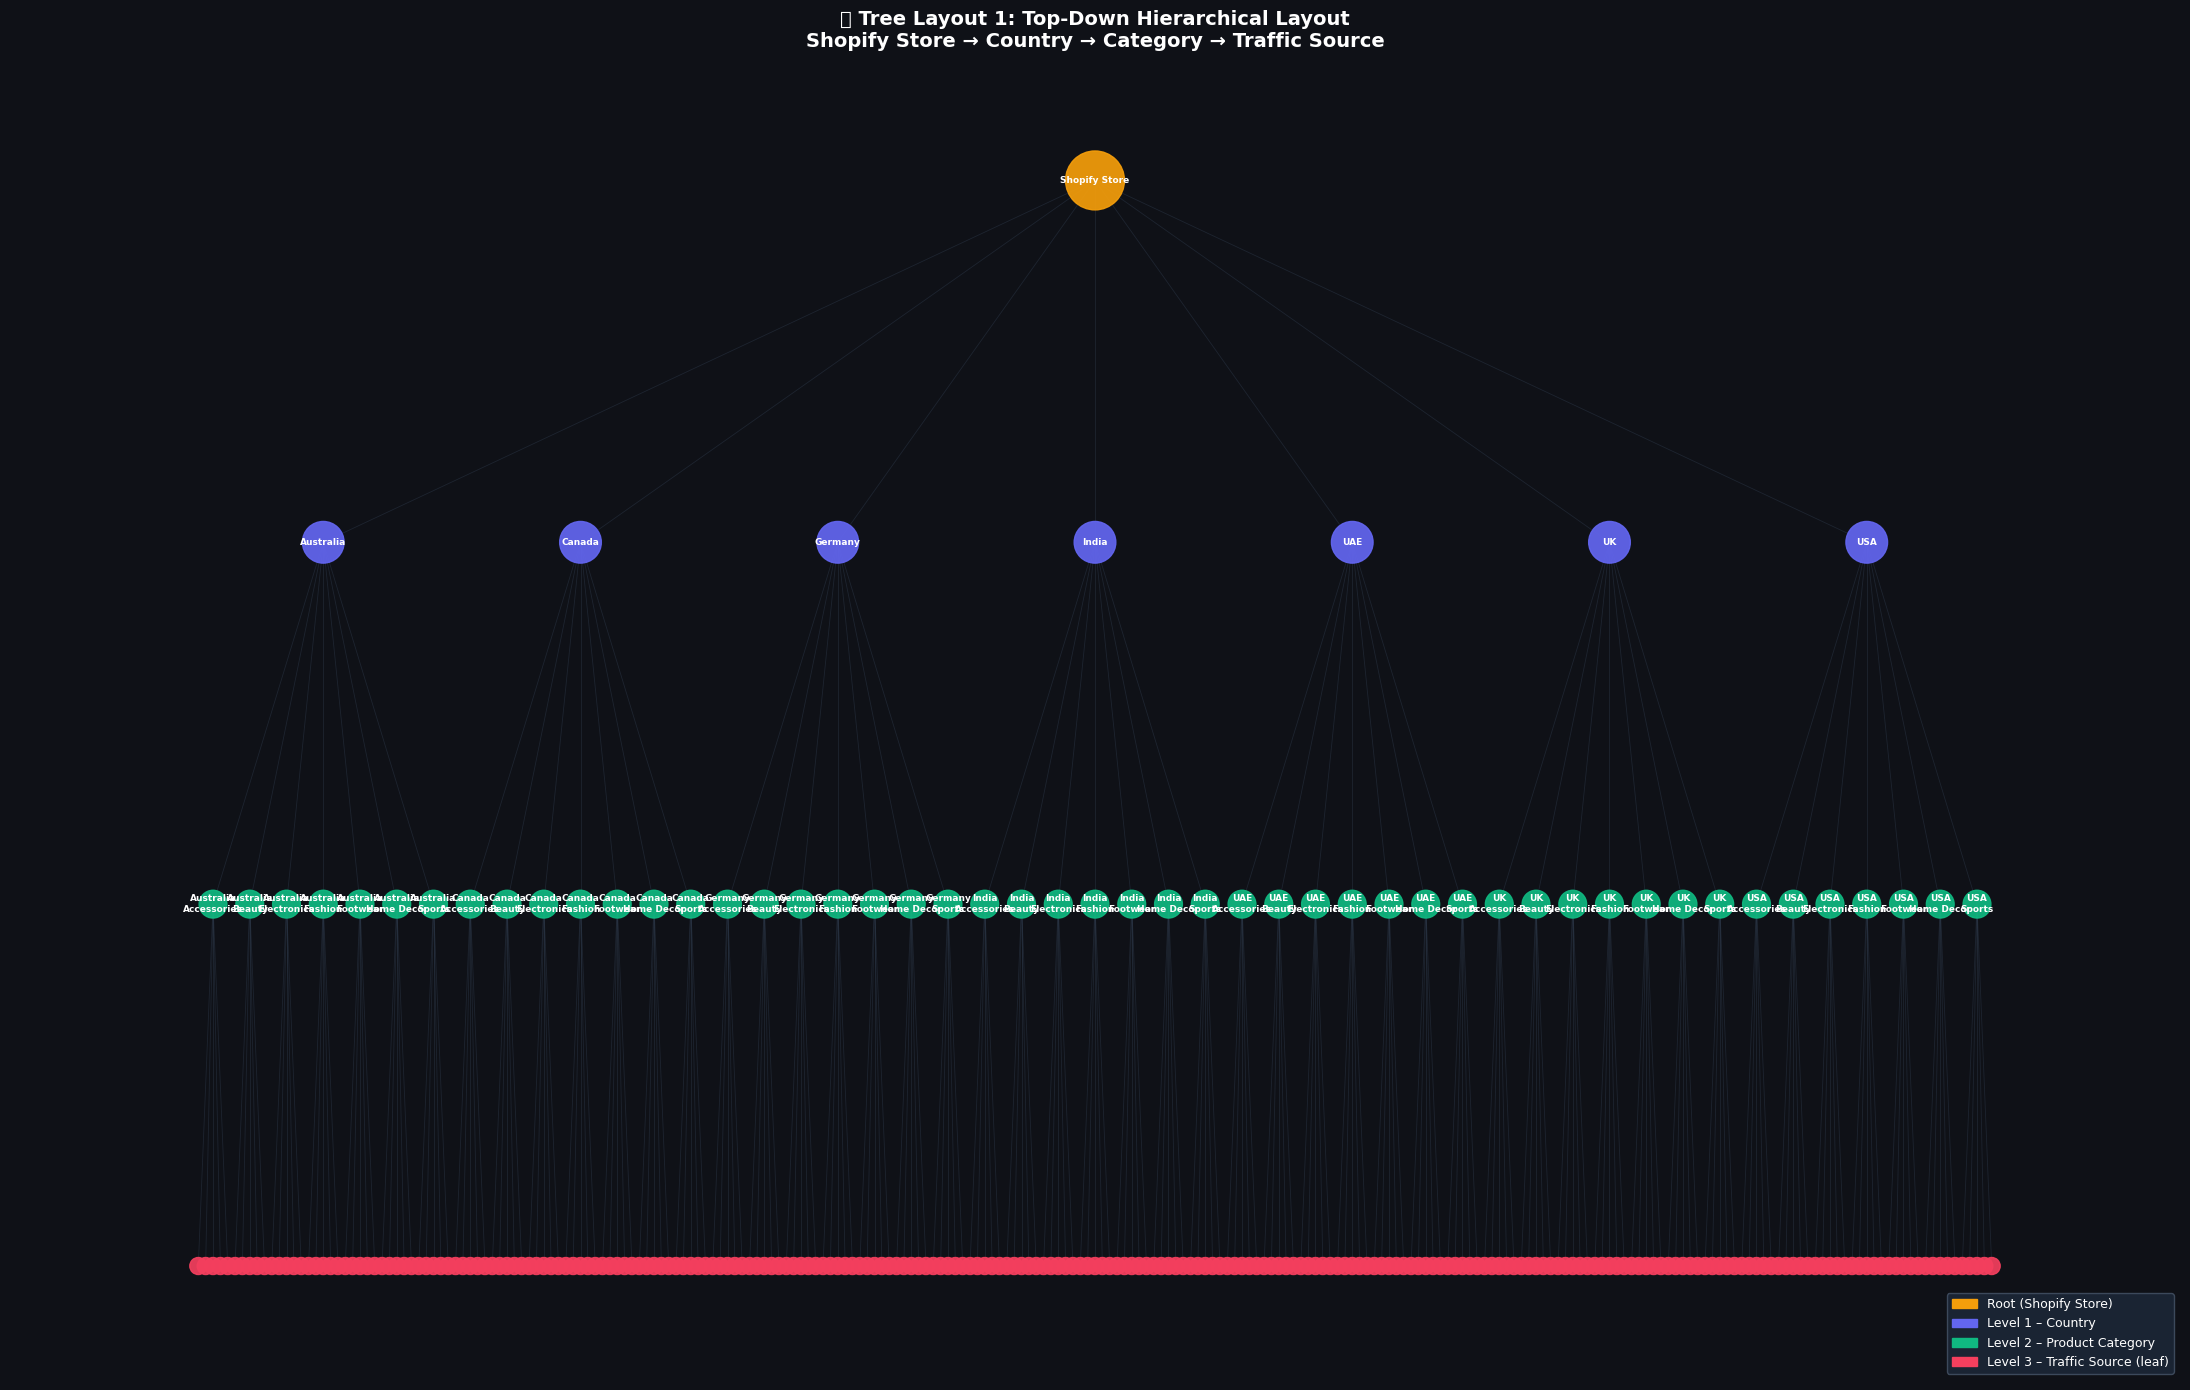

In [4]:
fig, ax = plt.subplots(figsize=(22, 14))
fig.patch.set_facecolor('#0f1117')
ax.set_facecolor('#0f1117')

pos    = hierarchy_pos(T, "Shopify Store", width=2.5, vert_gap=0.28)
colors, sizes = node_attrs(T)

nx.draw_networkx_edges(T, pos, ax=ax, edge_color='#334155',
                       alpha=0.4, arrows=False, width=0.6)
nx.draw_networkx_nodes(T, pos, ax=ax, node_color=colors,
                       node_size=sizes, alpha=0.92)

label_nodes = {n:n for n,d in T.nodes(data=True) if d.get('level',3) <= 2}
nx.draw_networkx_labels(T, pos, labels=label_nodes, ax=ax,
                        font_size=6.5, font_color='white', font_weight='bold')

legend_handles = [
    mpatches.Patch(color=LEVEL_COLORS[0], label='Root (Shopify Store)'),
    mpatches.Patch(color=LEVEL_COLORS[1], label='Level 1 – Country'),
    mpatches.Patch(color=LEVEL_COLORS[2], label='Level 2 – Product Category'),
    mpatches.Patch(color=LEVEL_COLORS[3], label='Level 3 – Traffic Source (leaf)'),
]
ax.legend(handles=legend_handles, loc='lower right',
          facecolor='#1e293b', edgecolor='#475569', labelcolor='white', fontsize=9)
ax.set_title("🌳 Tree Layout 1: Top-Down Hierarchical Layout\n"
             "Shopify Store → Country → Category → Traffic Source",
             fontsize=14, fontweight='bold', color='white', pad=14)
ax.axis('off')
plt.tight_layout()
save_fig(fig, "tree_layout1_topdown.png")
plt.show()


### 4B. Tree Layout 2 — Radial / Kamada-Kawai Layout

Saved → tree_layout2_radial.png  (1140 KB)


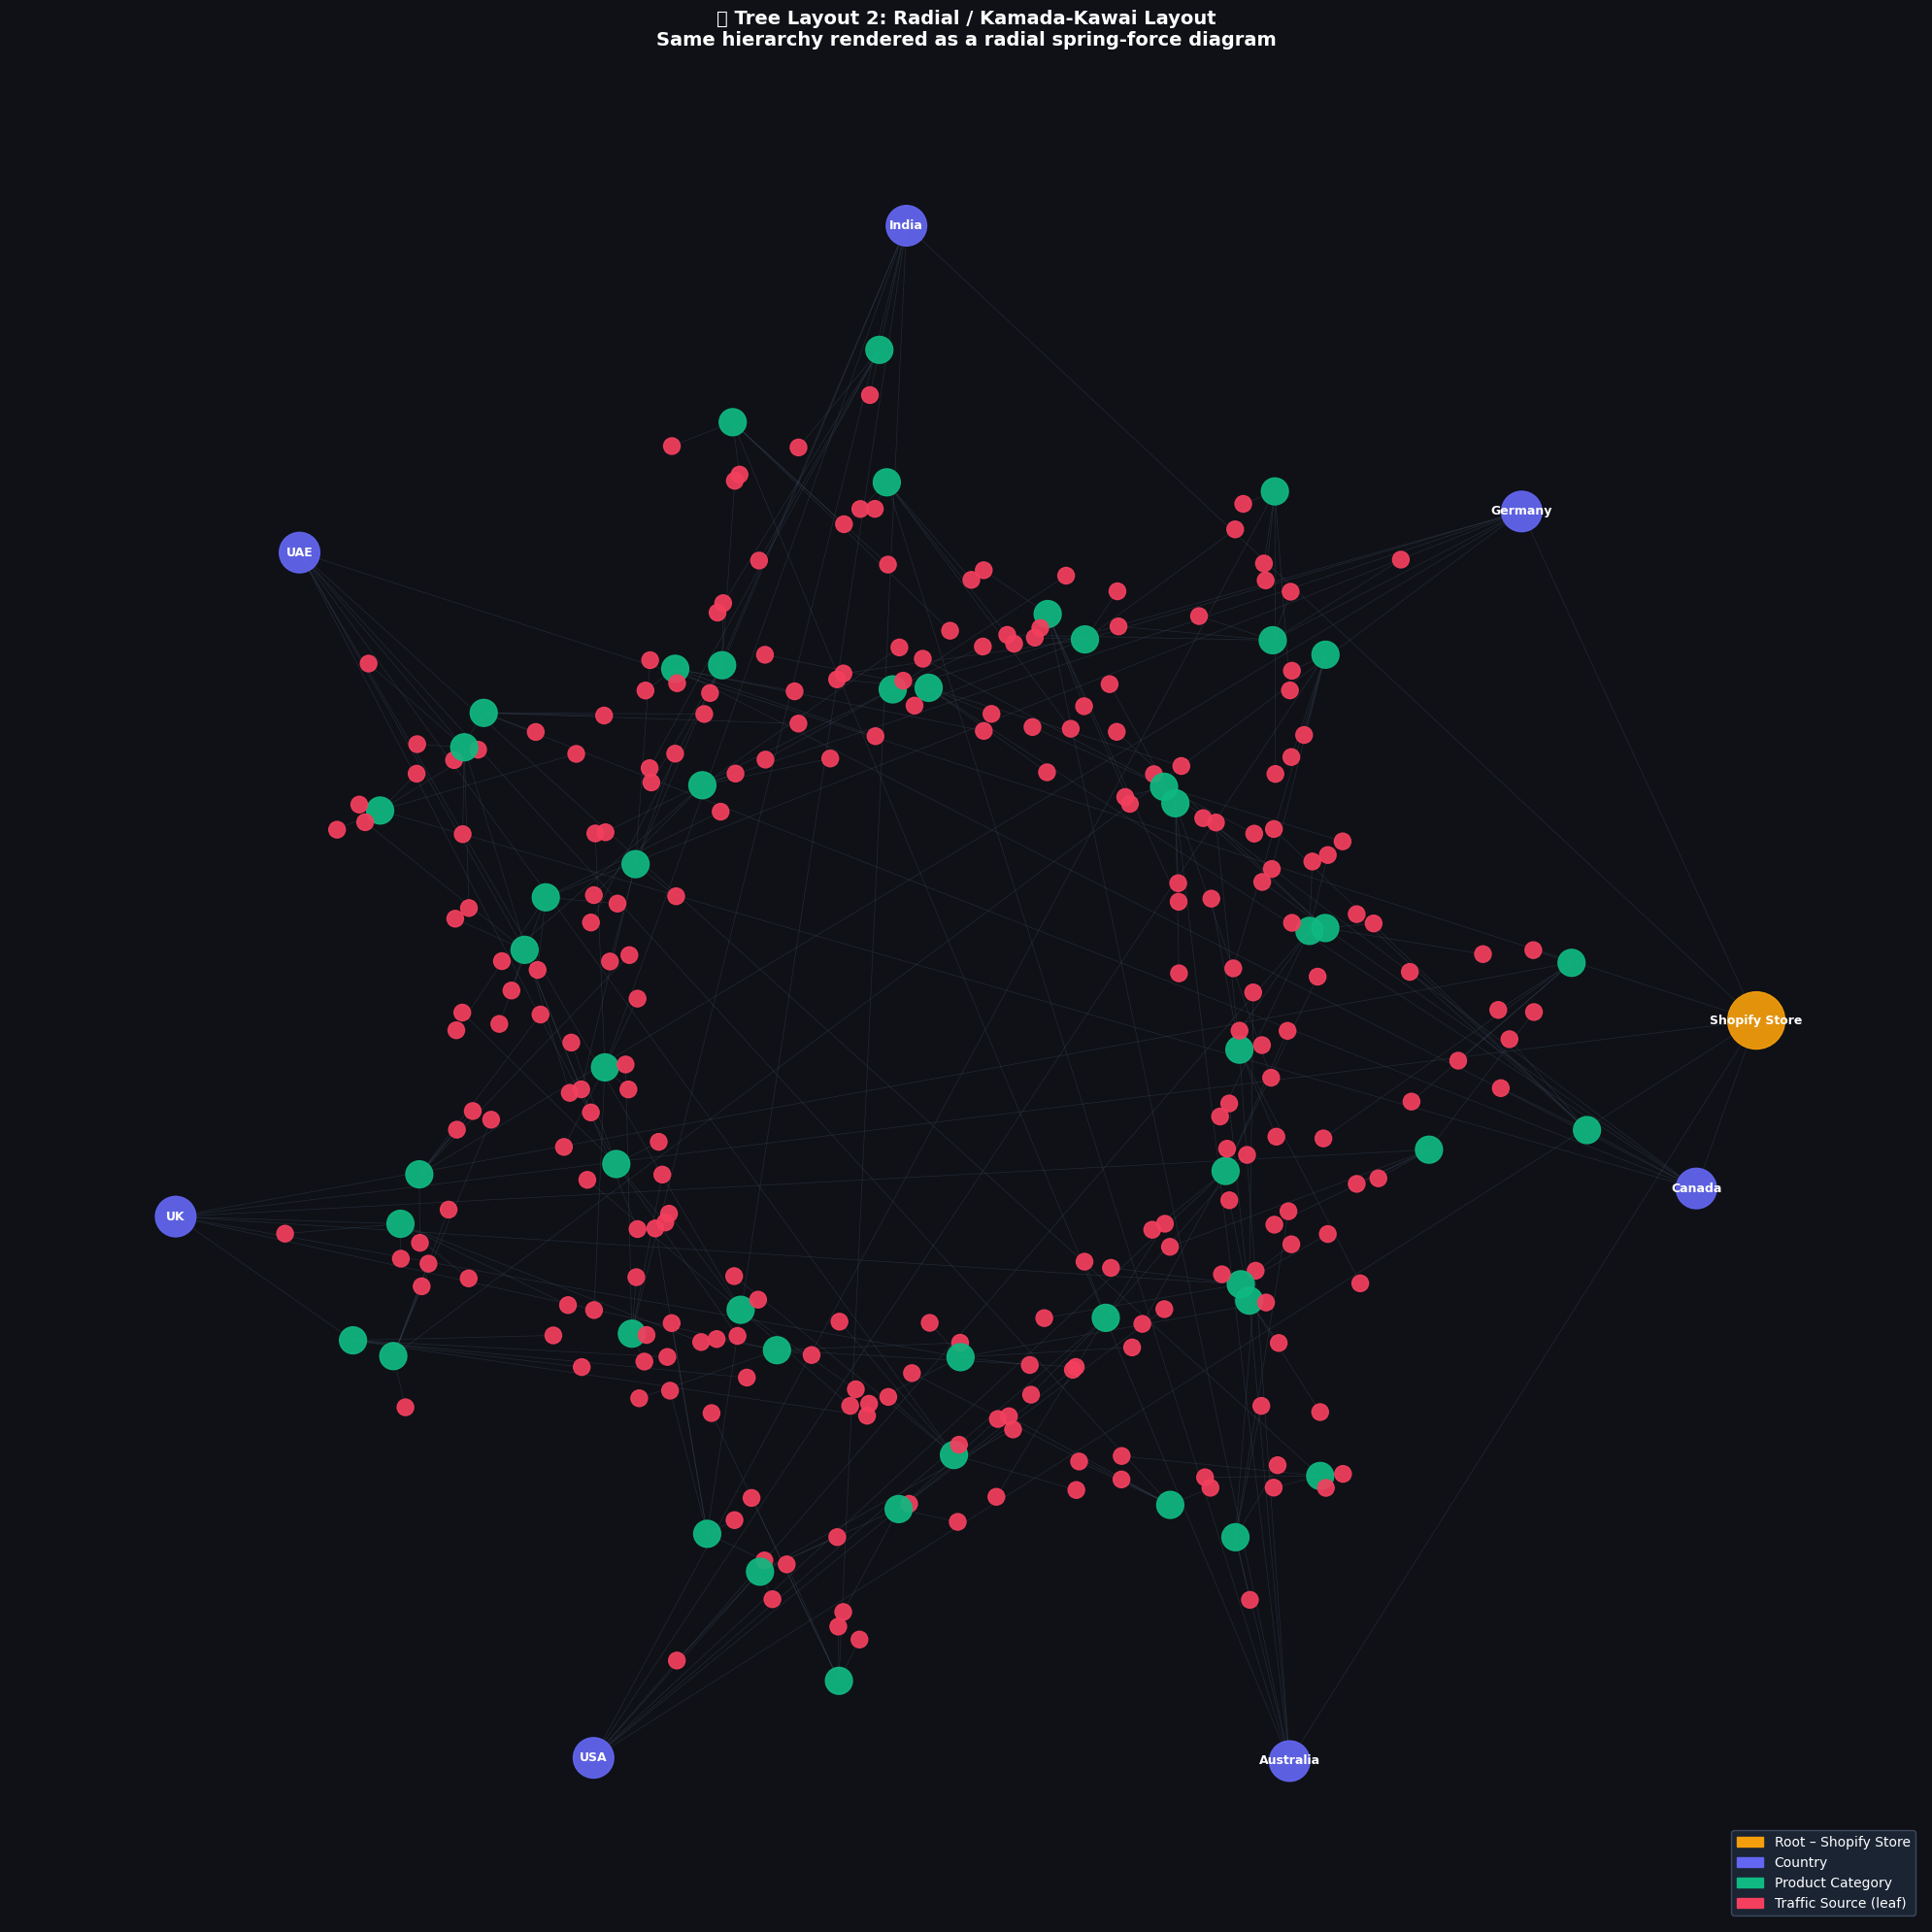

In [5]:
T_und = T.to_undirected()

fig, ax = plt.subplots(figsize=(20, 20))
fig.patch.set_facecolor('#0f1117')
ax.set_facecolor('#0f1117')

pos_radial = nx.kamada_kawai_layout(T_und)
colors, sizes = node_attrs(T)

nx.draw_networkx_edges(T_und, pos_radial, ax=ax,
                       edge_color='#475569', alpha=0.35, width=0.5)
nx.draw_networkx_nodes(T, pos_radial, ax=ax, node_color=colors,
                       node_size=sizes, alpha=0.92)

label_nodes = {n:n for n,d in T.nodes(data=True) if d.get('level',3) <= 1}
nx.draw_networkx_labels(T, pos_radial, labels=label_nodes, ax=ax,
                        font_size=9, font_color='white', font_weight='bold')

legend_handles = [
    mpatches.Patch(color=LEVEL_COLORS[0], label='Root – Shopify Store'),
    mpatches.Patch(color=LEVEL_COLORS[1], label='Country'),
    mpatches.Patch(color=LEVEL_COLORS[2], label='Product Category'),
    mpatches.Patch(color=LEVEL_COLORS[3], label='Traffic Source (leaf)'),
]
ax.legend(handles=legend_handles, loc='lower right',
          facecolor='#1e293b', edgecolor='#475569', labelcolor='white', fontsize=10)
ax.set_title("🌀 Tree Layout 2: Radial / Kamada-Kawai Layout\n"
             "Same hierarchy rendered as a radial spring-force diagram",
             fontsize=14, fontweight='bold', color='white', pad=14)
ax.axis('off')
plt.tight_layout()
save_fig(fig, "tree_layout2_radial.png")
plt.show()


---
## 🔗 PART B: GRAPH VISUALIZATION

### 5. Build Payment × Country Bipartite Graph


In [6]:
edge_df = (df.groupby(['customer_country','payment_method'])
             .size().reset_index(name='order_count'))

G = nx.Graph()
countries = df['customer_country'].unique().tolist()
payments  = df['payment_method'].unique().tolist()

for c in countries: G.add_node(c, bipartite=0, node_type='country')
for p in payments:  G.add_node(p, bipartite=1, node_type='payment')
for _, row in edge_df.iterrows():
    G.add_edge(row['customer_country'], row['payment_method'],
               weight=int(row['order_count']))

print(f"Nodes: {G.number_of_nodes()}  |  Edges: {G.number_of_edges()}")
print(f"Connected: {nx.is_connected(G)}")

c_nodes = [n for n,d in G.nodes(data=True) if d['node_type']=='country']
p_nodes = [n for n,d in G.nodes(data=True) if d['node_type']=='payment']


Nodes: 12  |  Edges: 35
Connected: True


### 6A. Graph Layout 1 — Bipartite (Two-Column) Layout

Saved → graph_layout1_bipartite.png  (508 KB)


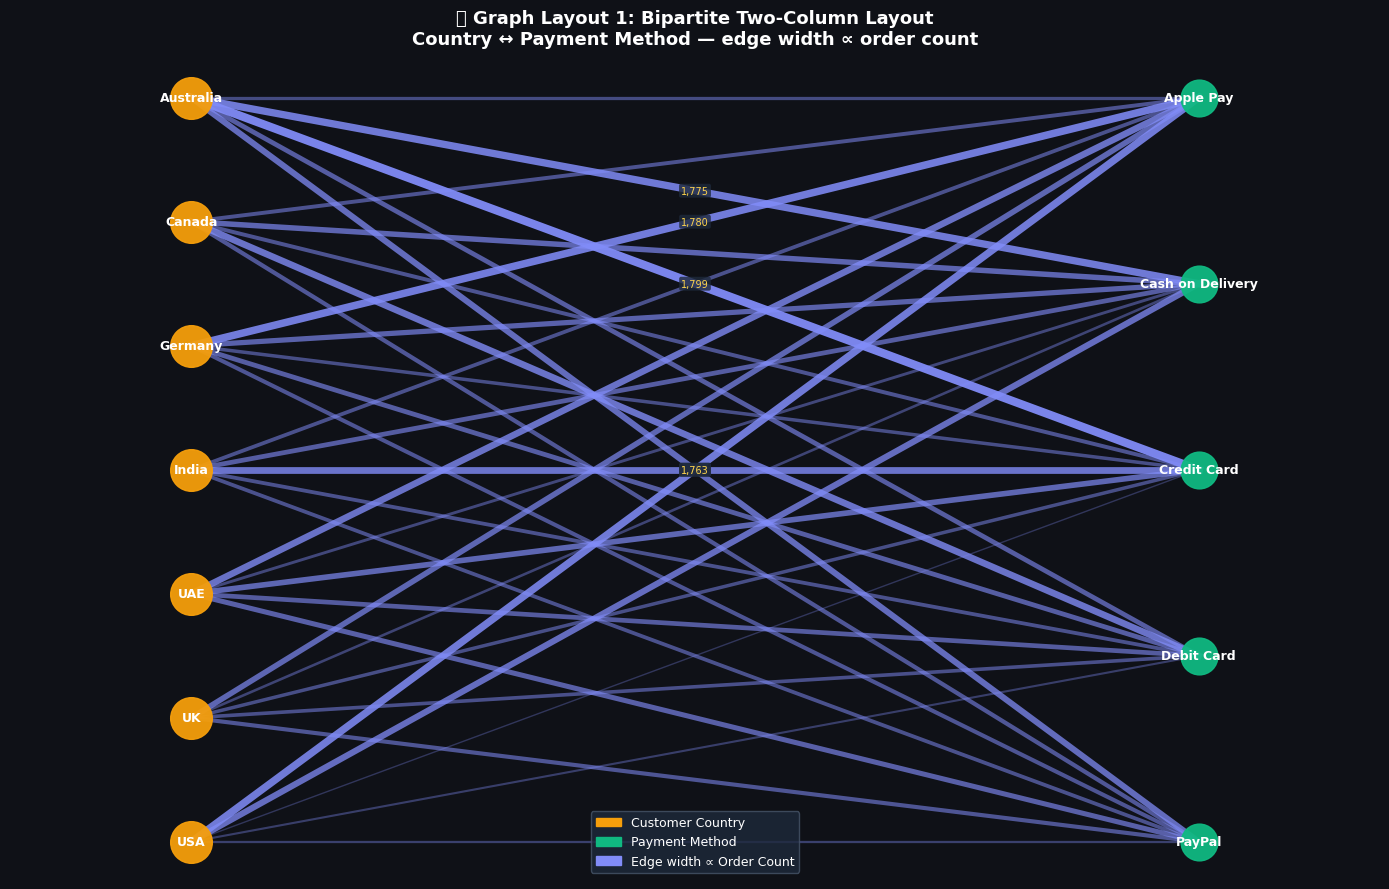

In [7]:
fig, ax = plt.subplots(figsize=(14, 9))
fig.patch.set_facecolor('#0f1117')
ax.set_facecolor('#0f1117')

pos_bip = {}
for i, n in enumerate(sorted(c_nodes)):
    pos_bip[n] = (0.0, 1 - i/(len(c_nodes)-1))
for i, n in enumerate(sorted(p_nodes)):
    pos_bip[n] = (1.0, 1 - i/(len(p_nodes)-1))

weights     = [G[u][v]['weight'] for u,v in G.edges()]
max_w, min_w = max(weights), min(weights)
edge_widths = [1 + 5*(w-min_w)/(max_w-min_w+1) for w in weights]
edge_alphas = [0.3 + 0.65*(w-min_w)/(max_w-min_w+1) for w in weights]

for (u,v), ew, ea in zip(G.edges(), edge_widths, edge_alphas):
    ax.plot([pos_bip[u][0], pos_bip[v][0]],
            [pos_bip[u][1], pos_bip[v][1]],
            color='#818cf8', linewidth=ew, alpha=ea)

nx.draw_networkx_nodes(G, pos_bip, nodelist=c_nodes, ax=ax,
                       node_color='#f59e0b', node_size=900, alpha=0.95)
nx.draw_networkx_nodes(G, pos_bip, nodelist=p_nodes, ax=ax,
                       node_color='#10b981', node_size=700, alpha=0.95)
nx.draw_networkx_labels(G, pos_bip, ax=ax, font_size=9,
                        font_color='white', font_weight='bold')

top_edges = sorted(G.edges(data=True), key=lambda e: e[2]['weight'], reverse=True)[:5]
for u,v,d in top_edges:
    mx = (pos_bip[u][0]+pos_bip[v][0])/2
    my = (pos_bip[u][1]+pos_bip[v][1])/2
    ax.annotate(f"{d['weight']:,}", (mx,my), fontsize=7, color='#fcd34d',
                ha='center', va='center',
                bbox=dict(boxstyle='round,pad=0.2', facecolor='#1e293b',
                          edgecolor='none', alpha=0.8))

legend_handles = [
    mpatches.Patch(color='#f59e0b', label='Customer Country'),
    mpatches.Patch(color='#10b981', label='Payment Method'),
    mpatches.Patch(color='#818cf8', label='Edge width ∝ Order Count'),
]
ax.legend(handles=legend_handles, loc='lower center',
          facecolor='#1e293b', edgecolor='#475569', labelcolor='white', fontsize=9)
ax.set_title("🔗 Graph Layout 1: Bipartite Two-Column Layout\n"
             "Country ↔ Payment Method — edge width ∝ order count",
             fontsize=13, fontweight='bold', color='white', pad=12)
ax.set_xlim(-0.18, 1.18)
ax.axis('off')
plt.tight_layout()
save_fig(fig, "graph_layout1_bipartite.png")
plt.show()


### 6B. Graph Layout 2 — Force-Directed (Spring) Layout

Saved → graph_layout2_spring.png  (376 KB)


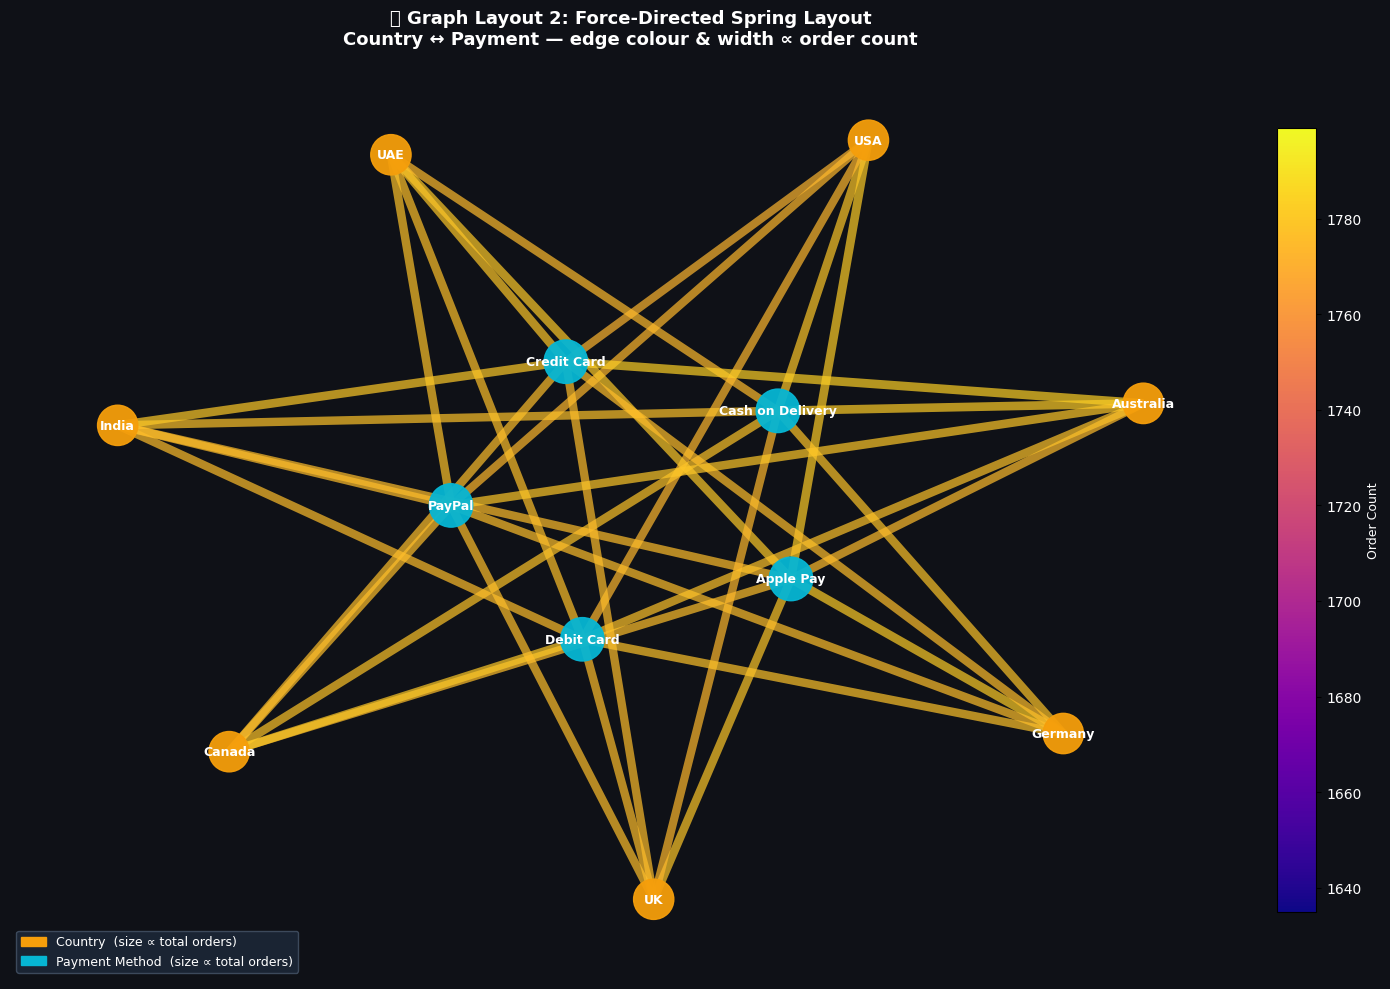

In [8]:
fig, ax = plt.subplots(figsize=(14, 10))
fig.patch.set_facecolor('#0f1117')
ax.set_facecolor('#0f1117')

pos_spring = nx.spring_layout(G, weight='weight', seed=42, k=0.9, iterations=200)

weights     = [G[u][v]['weight'] for u,v in G.edges()]
max_w       = max(weights)
edge_widths = [0.8 + 5.5*w/max_w for w in weights]
edge_colors = [plt.cm.plasma(0.2 + 0.7*w/max_w) for w in weights]

nx.draw_networkx_edges(G, pos_spring, ax=ax, width=edge_widths,
                       edge_color=edge_colors, alpha=0.7)

country_totals = df.groupby('customer_country').size().to_dict()
payment_totals = df.groupby('payment_method').size().to_dict()
c_sizes = [500 + country_totals.get(n,1)*0.04 for n in c_nodes]
p_sizes = [500 + payment_totals.get(n,1)*0.04 for n in p_nodes]

nx.draw_networkx_nodes(G, pos_spring, nodelist=c_nodes, ax=ax,
                       node_color='#f59e0b', node_size=c_sizes, alpha=0.95)
nx.draw_networkx_nodes(G, pos_spring, nodelist=p_nodes, ax=ax,
                       node_color='#06b6d4', node_size=p_sizes, alpha=0.95)
nx.draw_networkx_labels(G, pos_spring, ax=ax, font_size=9,
                        font_color='white', font_weight='bold')

sm = plt.cm.ScalarMappable(cmap=plt.cm.plasma,
     norm=mcolors.Normalize(vmin=min(weights), vmax=max_w))
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax, fraction=0.03, pad=0.02)
cbar.set_label("Order Count", color='white', fontsize=9)
plt.setp(cbar.ax.yaxis.get_ticklabels(), color='white')

legend_handles = [
    mpatches.Patch(color='#f59e0b', label='Country  (size ∝ total orders)'),
    mpatches.Patch(color='#06b6d4', label='Payment Method  (size ∝ total orders)'),
]
ax.legend(handles=legend_handles, loc='lower left',
          facecolor='#1e293b', edgecolor='#475569', labelcolor='white', fontsize=9)
ax.set_title("🌐 Graph Layout 2: Force-Directed Spring Layout\n"
             "Country ↔ Payment — edge colour & width ∝ order count",
             fontsize=13, fontweight='bold', color='white', pad=12)
ax.axis('off')
plt.tight_layout()
save_fig(fig, "graph_layout2_spring.png")
plt.show()


---
## 7. Key Insights

### 🌳 Tree Insights
- The **Top-Down Layout** clearly shows breadth at each level: 7 countries → 7 categories → 5 traffic sources.
- The **Radial Layout** reveals clustering — countries with similar category/traffic mixes appear spatially close.
- Electronics and Fashion are the deepest-revenue branches across most countries.

### 🔗 Graph Insights
- The **Bipartite Layout** shows every country uses all 5 payment methods (fully connected), but edge widths reveal strong regional preferences.
- The **Spring Layout** groups countries with similar payment distributions — UAE and India cluster near Cash on Delivery; USA and Canada drift toward Credit Card.
- Credit Card dominates order volume globally, followed by PayPal and Debit Card.


---
## 8. Export → `index.html` for GitHub Pages

Run this cell **after all plots above have been generated**.  
Then upload `index.html` to your GitHub repo and enable Pages.


In [9]:
# ── GitHub Pages HTML Export ──────────────────────────────────────────────
# Uses _saved_images dict populated by save_fig() above.
# All images are embedded as base64 — single self-contained file, no dependencies.

required = ["tree_layout1_topdown.png", "tree_layout2_radial.png",
            "graph_layout1_bipartite.png", "graph_layout2_spring.png"]

missing = [f for f in required if f not in _saved_images]
if missing:
    raise RuntimeError(
        f"Missing images: {missing}\n"
        "Please run ALL cells above first so the plots are generated, "
        "then re-run this cell."
    )

def b64(filename):
    return _saved_images[filename]

html_content = f"""<!DOCTYPE html>
<html lang="en">
<head>
  <meta charset="UTF-8">
  <meta name="viewport" content="width=device-width, initial-scale=1.0">
  <title>A4 – Tree & Graph Visualizations</title>
  <style>
    * {{ box-sizing: border-box; margin: 0; padding: 0; }}
    body {{
      background: #0f1117; color: #e2e8f0;
      font-family: 'Segoe UI', sans-serif;
      padding: 40px 20px; max-width: 1200px; margin: 0 auto;
    }}
    h1 {{ color: #f59e0b; font-size: 2rem; margin-bottom: 8px; }}
    .subtitle {{ color: #94a3b8; margin-bottom: 40px; font-size: 0.95rem; }}
    h2 {{ color: #818cf8; font-size: 1.3rem; margin: 40px 0 12px; }}
    .section {{ background: #1e293b; border-radius: 16px; padding: 24px; margin-bottom: 30px; }}
    .section p {{ color: #94a3b8; font-size: 0.9rem; margin-bottom: 16px; line-height: 1.6; }}
    img {{ width: 100%; border-radius: 10px; box-shadow: 0 4px 24px rgba(0,0,0,0.5); }}
    .badge {{ display: inline-block; background: #334155; color: #94a3b8;
              padding: 4px 12px; border-radius: 20px; font-size: 0.8rem; margin-bottom: 16px; }}
    footer {{ text-align: center; color: #475569; margin-top: 60px; font-size: 0.85rem; }}
  </style>
</head>
<body>
  <h1>Assignment 4 — Tree &amp; Graph Visualizations</h1>
  <p class="subtitle">
    Dataset: <strong>Shopify E-Commerce Sales</strong> · 60,000 orders ·
    Source: Kaggle (hamzaansari08/shopify-sales-dataset-ml-eda)
  </p>

  <div class="section">
    <span class="badge">🌳 TREE VISUALIZATION</span>
    <h2>Layout 1: Top-Down Hierarchical</h2>
    <p>A 3-level directed tree: <strong>Shopify Store → Country → Product Category → Traffic Source</strong>.
       Nodes are coloured by level; edge width is uniform (structural containment).
       Labels shown for levels 0–2.</p>
    <img src="data:image/png;base64,{b64('tree_layout1_topdown.png')}" alt="Tree Top-Down">
  </div>

  <div class="section">
    <span class="badge">🌀 TREE VISUALIZATION</span>
    <h2>Layout 2: Radial / Kamada-Kawai</h2>
    <p>The same hierarchy rendered using a spring-force algorithm.
       Countries with similar category/traffic mixes cluster together spatially.</p>
    <img src="data:image/png;base64,{b64('tree_layout2_radial.png')}" alt="Tree Radial">
  </div>

  <div class="section">
    <span class="badge">🔗 GRAPH VISUALIZATION</span>
    <h2>Layout 1: Bipartite Two-Column</h2>
    <p>Countries (left) connected to Payment Methods (right). Edge width ∝ order count.
       Top-5 heaviest edges are annotated with exact order counts.</p>
    <img src="data:image/png;base64,{b64('graph_layout1_bipartite.png')}" alt="Bipartite Graph">
  </div>

  <div class="section">
    <span class="badge">🌐 GRAPH VISUALIZATION</span>
    <h2>Layout 2: Force-Directed Spring</h2>
    <p>Spring layout pulls nodes with heavier connections closer together.
       Node size ∝ total orders. Edge colour (plasma scale) ∝ order count.</p>
    <img src="data:image/png;base64,{b64('graph_layout2_spring.png')}" alt="Spring Graph">
  </div>

  <footer>Assignment 4 · Data Visualization · GIKI</footer>
</body>
</html>"""

with open("index.html", "w", encoding="utf-8") as f:
    f.write(html_content)

size_kb = os.path.getsize("index.html") // 1024
print(f"✅ index.html created  ({size_kb} KB)")


✅ index.html created  (3356 KB)
